In [1]:
import numpy as np
import pandas as pd
import warnings
warnings.simplefilter('ignore')

In [2]:
X_train = pd.read_csv('X_train.csv')
X_test = pd.read_csv('X_test.csv')
y_train = pd.read_csv('y_train.csv')
y_test = pd.read_csv('y_test.csv')
X=pd.concat([X_train,X_test])
y=pd.concat([y_train,y_test])

In [3]:
# Using the best decision tree model as observed in the last lecture
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import KFold, cross_validate

tree_clf = DecisionTreeClassifier(random_state=7, max_depth = 4)
kfold = KFold(n_splits=10)
cv_acc_results = cross_validate(tree_clf, X, y, cv = kfold, scoring = 'accuracy', return_train_score = True)

print(f"K-Fold Accuracy Mean: Train: {cv_acc_results['train_score'].mean().round(3)*100} Validation: {cv_acc_results['test_score'].mean().round(3)*100}")

K-Fold Accuracy Mean: Train: 87.9 Validation: 84.0


# RandomForest

In [4]:
from sklearn.ensemble import RandomForestClassifier

In [5]:
rfc = RandomForestClassifier(random_state=7, n_estimators=300, max_depth=6)
kfold = KFold(n_splits=10)
cv_acc_results = cross_validate(rfc, X, y, cv = kfold, scoring = 'accuracy' ,return_train_score = True)

print(f"K-Fold Accuracy Mean: Train: {cv_acc_results['train_score'].mean().round(3)*100} Validation: {cv_acc_results['test_score'].mean().round(3)*100}")

K-Fold Accuracy Mean: Train: 89.0 Validation: 85.7


In [6]:
rfc = RandomForestClassifier(random_state=7, n_estimators=300, max_depth=6, oob_score=True)
rfc.fit(X, y)
rfc.oob_score_

0.8578231292517007

In [7]:
rfc.estimators_[:4]

[DecisionTreeClassifier(max_depth=6, max_features='sqrt', random_state=327741615),
 DecisionTreeClassifier(max_depth=6, max_features='sqrt', random_state=976413892),
 DecisionTreeClassifier(max_depth=6, max_features='sqrt',
                        random_state=1202242073),
 DecisionTreeClassifier(max_depth=6, max_features='sqrt',
                        random_state=1369975286)]

In [8]:
importances = rfc.feature_importances_
importances

array([0.06478715, 0.04184251, 0.03717564, 0.01196233, 0.02303447,
       0.0265845 , 0.00508772, 0.03370896, 0.02112521, 0.02744522,
       0.04912358, 0.02038443, 0.08589207, 0.03584472, 0.02830553,
       0.09945745, 0.02493685, 0.00289181, 0.01578714, 0.04139934,
       0.06112269, 0.01948047, 0.02195416, 0.04645471, 0.02389513,
       0.01811583, 0.03373602, 0.00454005, 0.01672735, 0.00538822,
       0.00223163, 0.00689513, 0.00675116, 0.00591654, 0.00676579,
       0.02324848])

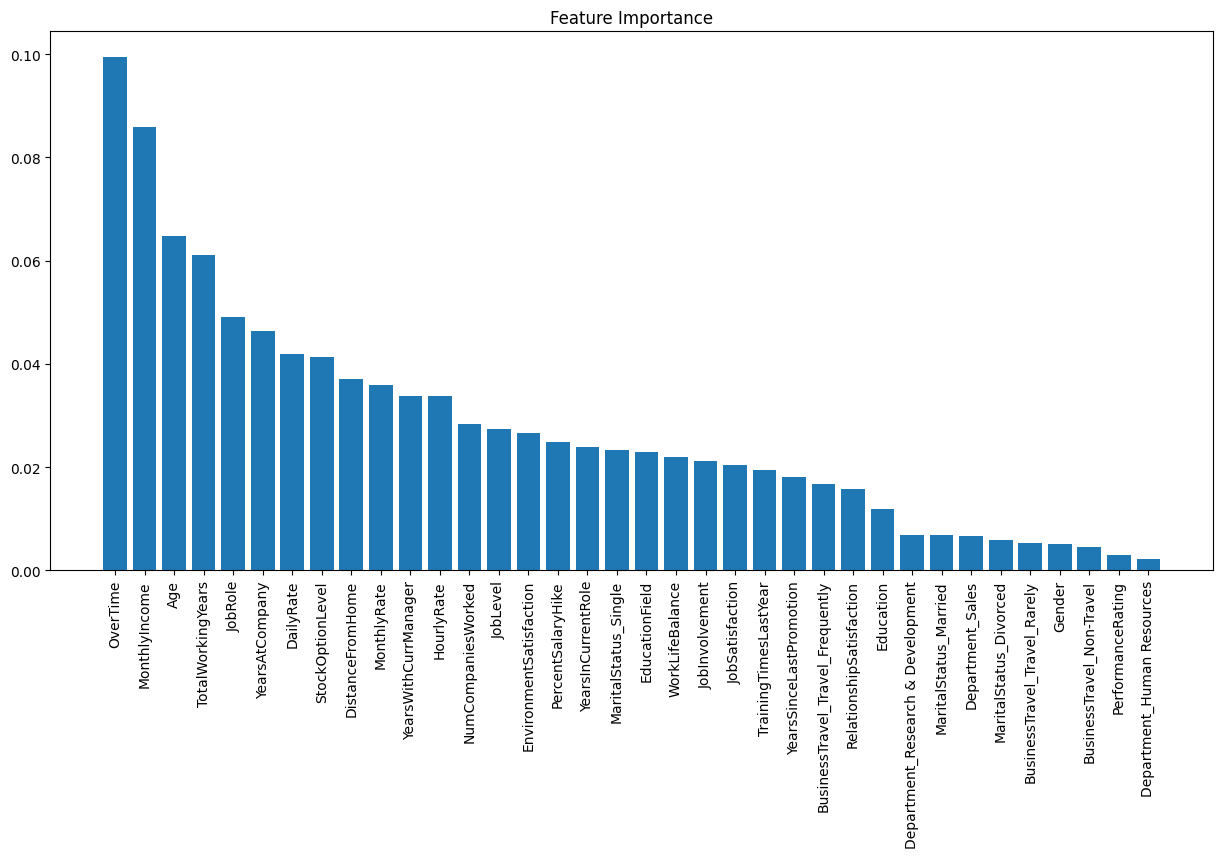

In [9]:
import numpy as np
import matplotlib.pyplot as plt

indices = np.argsort(importances)[::-1] # Sort feature importances in descending order
names = [X.columns[i] for i in indices] # Rearrange feature names so they match the sorted feature importances
plt.figure(figsize=(15, 7)) # Create plot
plt.title("Feature Importance") # Create plot title
plt.bar(range(X.shape[1]), importances[indices]) # Add bars
plt.xticks(range(X.shape[1]), names, rotation=90) # Add feature names as x-axis labels
plt.show() # Show plot

In [10]:
%%time
#>> 16 s
rfc = RandomForestClassifier(random_state=7, n_estimators=300, max_depth=6)
kfold = KFold(n_splits=10)
cv_acc_results = cross_validate(rfc, X, y, cv = kfold, scoring = 'accuracy' ,return_train_score = True)

print(f"K-Fold Accuracy Mean: Train: {cv_acc_results['train_score'].mean().round(3)*100} Validation: {cv_acc_results['test_score'].mean().round(3)*100}")

K-Fold Accuracy Mean: Train: 89.0 Validation: 85.7
CPU times: total: 9.98 s
Wall time: 15.9 s


In [11]:
%%time
#>> 13 s
rfc = RandomForestClassifier(random_state=7, n_estimators=300, max_depth=6, n_jobs=-1)
kfold = KFold(n_splits=10)
cv_acc_results = cross_validate(rfc, X, y, cv = kfold, scoring = 'accuracy' ,return_train_score = True)

print(f"K-Fold Accuracy Mean: Train: {cv_acc_results['train_score'].mean().round(3)*100} Validation: {cv_acc_results['test_score'].mean().round(3)*100}")

K-Fold Accuracy Mean: Train: 89.0 Validation: 85.7
CPU times: total: 3.8 s
Wall time: 7.89 s


In [12]:
from sklearn.model_selection import GridSearchCV

In [13]:
params2explore = {"n_estimators":[100,200,300,400], #4
                  "max_depth":[3,5,7,8,10] # 5
                  }

In [14]:
rfc = RandomForestClassifier()
model = GridSearchCV(rfc, params2explore,scoring="accuracy",n_jobs=-1, cv=3, return_train_score=True)

In [15]:
model.fit(X, y)

GridSearchCV(cv=3, estimator=RandomForestClassifier(), n_jobs=-1,
             param_grid={'max_depth': [3, 5, 7, 8, 10],
                         'n_estimators': [100, 200, 300, 400]},
             return_train_score=True, scoring='accuracy')

In [16]:
print(model.cv_results_['mean_train_score'])

[0.85204082 0.84931973 0.85034014 0.85136054 0.87789116 0.87721088
 0.87721088 0.87857143 0.92653061 0.92891156 0.92755102 0.9255102
 0.95578231 0.95068027 0.95544218 0.95612245 0.98809524 0.99081633
 0.9877551  0.98877551]


In [17]:
model.best_score_

0.8591836734693877

In [18]:
model.best_params_

{'max_depth': 10, 'n_estimators': 200}

- https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html
- https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html
- https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html
- https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.ExtraTreesClassifier.html